## Сборка и анализ первого датасета

In [110]:
import os
from pathlib import Path
import zipfile
import shutil
from glob import glob
import sys

from PIL import Image
import numpy as np
import pandas as pd
from skimage import measure
import json


import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW
from torch import nn
import tqdm
from sklearn.model_selection import train_test_split
import albumentations
import segmentation_models_pytorch as smp
import warnings
warnings.filterwarnings("ignore")

In [2]:
cur_dir = os.path.curdir
dataset_dir = os.path.join(cur_dir, "dataset")

In [5]:
train_data_dir = os.path.join(dataset_dir, "train")

In [5]:
try:
    shutil.rmtree(pred_data_dir)
    shutil.rmtree(dataset_dir)
except Exception as e:
    ...

### Создание нужных вложенных папок

In [7]:
os.makedirs("dataset/train", exist_ok=True)
os.makedirs("dataset/test", exist_ok=True)
os.makedirs("dataset/val", exist_ok=True)

In [8]:
os.makedirs("dataset/train/masks", exist_ok=True)
os.makedirs("dataset/train/images", exist_ok=True)

In [9]:
os.makedirs("dataset/train/masks", exist_ok=True)
os.makedirs("dataset/train/images", exist_ok=True)

### Сборка и анализ

In [7]:
pred_data_dir = os.path.join(dataset_dir, "pred_data")

In [12]:
with zipfile.ZipFile("archive.zip") as f:
    f.extractall(pred_data_dir)

In [9]:
pred_train_dir = os.path.join(pred_data_dir, "train")
pred_test_dir = os.path.join(pred_data_dir, "test")
pred_val_dir = os.path.join(pred_data_dir, "valid")

In [11]:
train_files = os.listdir(pred_train_dir)
test_files = os.listdir(pred_test_dir)
val_files = os.listdir(pred_val_dir)
all_files = []
all_files.extend(train_files + test_files + val_files)

In [13]:
print("Total files:", len(all_files))

Total files: 6779


In [15]:
images_path = list()
masks_path = list()

for file in train_files:
    if "_mask" in file:
        masks_path.append(os.path.join(pred_train_dir, file))
        continue
    images_path.append(os.path.join(pred_train_dir, file))
    
for file in test_files:
    if "_mask" in file:
        masks_path.append(os.path.join(pred_test_dir, file))
        continue
    images_path.append(os.path.join(pred_test_dir, file))
for file in val_files:
    if "_mask" in file:
        masks_path.append(os.path.join(pred_val_dir, file))
        continue
    images_path.append(os.path.join(pred_val_dir, file))

In [17]:
print("Images Length:", len(images_path))
print("Masks Length:", len(masks_path))

Images Length: 3391
Masks Length: 3388


In [19]:
train_masks = os.path.join(train_data_dir, "masks")
try:
    for mask_path in masks_path:
        filename = os.path.basename(mask_path)  # только имя файла
        dst_path = os.path.join(train_masks, filename)

        if not os.path.exists(dst_path):
            shutil.move(mask_path, dst_path)
except Exception as e:
    print(e)

In [21]:
train_images = os.path.join(train_data_dir, "images")
try:
    for image_path in images_path:
        filename = os.path.basename(image_path)  # только имя файла
        dst_path = os.path.join(train_images, filename)

        if not os.path.exists(dst_path):
            shutil.move(image_path, dst_path)
except Exception as e:
    print(e)

In [23]:
print("Images Length:", len(os.listdir(train_images)))
print("Masks Length:", len(os.listdir(train_masks)))

Images Length: 3389
Masks Length: 3388


## Конвертация масок

In [25]:
train_images = glob(f'{train_images}/*.jpg')
train_masks = glob(f'{train_masks}/*.png')

In [27]:
print("Images Length:", len(train_images))
print("Masks Length:", len(train_masks))

Images Length: 3388
Masks Length: 3388


In [29]:
# Проверка на соответствие
for i in range(5):
    print(os.path.basename(train_images[i]).split(".")[0], os.path.basename(train_masks[i]).split(".")[0])

01_taylor_jpeg_jpg 01_taylor_jpeg_jpg
037ff865416549-5af427762eb81_jpg 037ff865416549-5af427762eb81_jpg
037ff865416549-5af427762eb81_jpg 037ff865416549-5af427762eb81_jpg
037ff865416549-5af427762eb81_jpg 037ff865416549-5af427762eb81_jpg
0517-ABIGSPILL-02-GULF-COAST-ENVIRONMENT-OIL-SPILL_jpg 0517-ABIGSPILL-02-GULF-COAST-ENVIRONMENT-OIL-SPILL_jpg


In [25]:
# Получение COCO-аннотаций по признакам из изображений
### Для Mask R-CNN ###
def convert_masks(train_images, train_masks, output_json):
    categories = [{"id": 1, "name": "oil_spill"}]
    coco = {
        "images": [],
        "annotations": [],
        "categories": categories
    }
    ann_id = 1
    for image_id, (img_path, mask_path) in enumerate(zip(train_images, train_masks), start=1):
        with Image.open(img_path) as img:
            width, height = img.size
        
        coco["images"].append({
            "id": image_id,
            "file_name": os.path.basename(img_path),
            "width": width,
            "height": height
        })
        mask = np.array(Image.open(mask_path).convert("L"))
        mask = (mask > 0).astype(np.uint8)
        
        labeled_mask = measure.label(mask)
        regions = measure.regionprops(labeled_mask)
        
        for region in regions:
            if region.area < 50: 
                continue
            
            min_row, min_col, max_row, max_col = region.bbox
            bbox = [min_col, min_row, max_col - min_col, max_row - min_row]
            
            contours = measure.find_contours(labeled_mask == region.label, 0.5)
            segmentation = []
            for contour in contours:
                contour = np.flip(contour, axis=1)
                segmentation.append(contour.ravel().tolist())
            
            coco["annotations"].append({
                "id": ann_id,
                "image_id": image_id,
                "category_id": 1,
                "segmentation": segmentation,
                "bbox": bbox,
                "iscrowd": 0,
                "area": region.area
            })
            ann_id += 1
    
    os.makedirs(os.path.dirname(output_json), exist_ok=True)
    with open(output_json, "w") as f:
        json.dump(coco, f)
    print(f"Аннотации сохранены в {output_json}")

In [26]:
annotations_path = os.path.join(train_data_dir, "annotations.json")

In [27]:
convert_masks(train_images, train_masks, output_json=annotations_path)

Аннотации сохранены в .\dataset\train\annotations.json


In [28]:
# shutil.move(os.path.join(dataset_dir, "annotations/annotations.json"), train_data_dir)

In [31]:
train_images_path = os.path.join(dataset_dir, "train/images")
train_masks_path = os.path.join(dataset_dir, "train/masks")

In [33]:
# Получение пар изображений и масок
pairs = list(zip(train_images, train_masks))

## Визуализация данных

In [114]:
import matplotlib.pyplot as plt
import random

In [33]:
random_image_index = random.randrange(0, len(train_images))

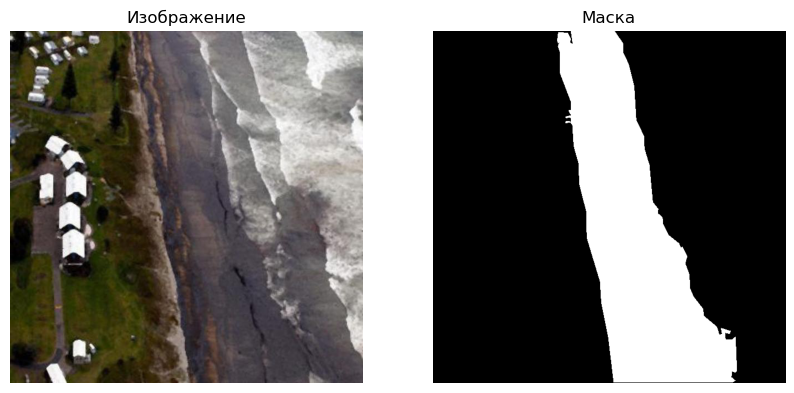

In [269]:
random_image_index = random.randrange(0, len(train_images))

img = Image.open(pairs[random_image_index][0])
mask = Image.open(pairs[random_image_index][1])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img)
axs[0].set_title("Изображение")
axs[0].axis("off")

axs[1].imshow(mask, cmap="gray")
axs[1].set_title("Маска")
axs[1].axis("off")

plt.show()

## Кастомный датасет

In [35]:
class OilData(Dataset):
    def __init__(self, pairs, transforms=None):
        self.pairs = pairs
        self.transforms = transforms

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        # mask должна быть от 0 до 5 (int)
        mask = mask.astype("int64")

        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]
        else:
            img = img.transpose(2, 0, 1).astype("float32") / 255.0
            img = torch.from_numpy(img).float()
            mask = torch.from_numpy(mask).long()

        return img, mask

## Поточное аугментирование и загрузка данных

In [38]:
train_transform = albumentations.Compose([
    albumentations.RandomResizedCrop(
        size=(512, 512), 
        scale=(0.8, 1.0),
        p=1.0
    ),
    albumentations.HorizontalFlip(p=0.5),
    albumentations.VerticalFlip(p=0.2),
    albumentations.RandomRotate90(p=0.5),
    albumentations.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    albumentations.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
    albumentations.ColorJitter(p=0.4),
    albumentations.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    albumentations.ToTensorV2()
])

In [40]:
val_transform = albumentations.Compose([
    albumentations.Resize(512, 512),
    albumentations.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    albumentations.ToTensorV2()
])

In [42]:
train_pairs, val_pairs = train_test_split(pairs, test_size=0.15, random_state=42)
train_ds = OilData(train_pairs, transforms=train_transform)
val_ds   = OilData(val_pairs, transforms=val_transform)

In [46]:
BATCH_SIZE = 8

In [48]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

In [50]:
imgs, masks = next(iter(train_loader))

## Инициализация модели и цикл обучения

In [54]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [56]:
model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    decoder_attention_type="scse",
    in_channels=3,
    classes=6,
    activation=None
).to(DEVICE)

In [60]:
criterion = nn.CrossEntropyLoss()  # (логиты, target int64)
optimizer = AdamW(model.parameters(), lr=0.0001, weight_decay=0.00005)

In [62]:
def iou_score(preds, targets, num_classes=6, ignore_index=None):
    preds = torch.argmax(preds, dim=1) 
    ious = []
    for cls in range(num_classes):
        if cls == ignore_index:
            continue
        pred_inds = (preds == cls)
        target_inds = (targets == cls)
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union == 0:
            continue
        ious.append(intersection / union)
    if len(ious) == 0:
        return 0.0
    return sum(ious) / len(ious) 

In [64]:
best_val_iou = 0.0

## Обучение модели

In [66]:
NUM_EPOCHS = 15

In [68]:
print("device:", DEVICE)

device: cuda


In [70]:
for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    train_loss = 0.0
    for imgs, masks in tqdm.tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]"):
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE, dtype=torch.long)

        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    with torch.no_grad():
        for imgs, masks in tqdm.tqdm(val_loader, desc=f"Эпоха {epoch}/{NUM_EPOCHS} [val]"):
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE, dtype=torch.long)

            preds = model(imgs)
            loss = criterion(preds, masks)

            val_loss += loss.item() * imgs.size(0)
            val_iou += iou_score(preds, masks) * imgs.size(0)

    val_loss /= len(val_loader.dataset)
    val_iou /= len(val_loader.dataset)

    print(f"Эпоха {epoch}: loss={train_loss:.4f} | val_loss={val_loss:.4f} | mIoU={val_iou:.4f}")

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), "best_model2.pth")
        print(f"Модель сохранена с результатом {val_iou:.4f}")

Эпоха 1/15 [val]: 100%|██████████| 64/64 [00:17<00:00,  3.70it/s]


Эпоха 1: loss=1.3165 | val_loss=0.9892 | mIoU=0.3154
✅ Модель сохранена с результатом 0.3154


Эпоха 2/15 [val]: 100%|██████████| 64/64 [00:16<00:00,  3.92it/s]


Эпоха 2: loss=1.0435 | val_loss=0.8335 | mIoU=0.3724
✅ Модель сохранена с результатом 0.3724


Эпоха 3/15 [val]: 100%|██████████| 64/64 [00:17<00:00,  3.70it/s]


...

Эпоха 13: loss=0.6381 | val_loss=0.4902 | mIoU=0.5864
✅ Модель сохранена с результатом 0.5864


Эпоха 14/15 [val]: 100%|██████████| 64/64 [00:17<00:00,  3.73it/s]


Эпоха 14: loss=0.6288 | val_loss=0.4946 | mIoU=0.5917
✅ Модель сохранена с результатом 0.5917


Эпоха 15/15 [val]: 100%|██████████| 64/64 [00:16<00:00,  3.92it/s]

Эпоха 15: loss=0.6174 | val_loss=0.4798 | mIoU=0.5906


## Тестирование модели

In [123]:
!nvidia-smi

Thu Sep 25 20:59:35 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.88                 Driver Version: 576.88         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   43C    P5             19W /  200W |    1900MiB /  12282MiB |     35%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [72]:
model.load_state_dict(torch.load("best_model2.pth", map_location=DEVICE))

<All keys matched successfully>

In [74]:
model.to(DEVICE)

UnetPlusPlus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [162]:
test_data = os.path.join(dataset_dir, 'test')
test_files = os.listdir(test_data)

In [179]:
example = os.path.join(test_data, test_files[0])

img = Image.open(example).convert("RGB")
img = np.array(img)

transform = albumentations.Compose([
    albumentations.Resize(512, 512, interpolation=cv2.INTER_NEAREST)
])
transformed = val_transform(image=img)
img_tensor = transformed["image"].unsqueeze(0).to(DEVICE)

In [233]:
temperature = 1.3

In [251]:
model.eval()
with torch.no_grad():
    pred = model(img_tensor)
    probs = torch.softmax(pred / temperature, dim=1)
    pred_mask = torch.argmax(probs, dim=1).squeeze().cpu().numpy()

pred_mask = pred_mask.astype(np.uint8) 
if pred_mask.ndim == 3 and pred_mask.shape[0] == 1:
    pred_mask = pred_mask[0] 

In [257]:
print("Уникальные классы:", np.unique(pred_mask))

Уникальные классы: [0 4]


In [253]:
transformed_img = transform(image=img)["image"]
transformed_mask = transform(image=pred_mask)["image"]

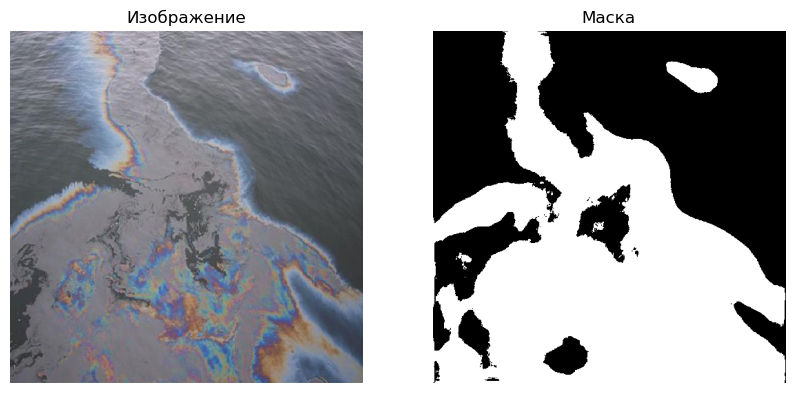

In [255]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(transformed_img, cmap="gray")
axs[0].set_title("Изображение")
axs[0].axis("off")

axs[1].imshow(transformed_mask, cmap="gray")
axs[1].set_title("Маска")
axs[1].axis("off")

plt.show()